In [950]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [951]:
data = pd.read_csv("dirty_cafe_sales.csv")
print(data.isnull().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [952]:
data = data.drop('Transaction ID', axis=1, errors='ignore')
data_clone = data.copy()
data2 = ['Item', 'Payment Method', 'Location']
data3 = ['Quantity', 'Price Per Unit', 'Total Spent']



In [953]:
for col in data.columns:
    data[col] = data[col].replace(['ERROR', 'UNKNOWN'], np.nan)
    data_clone[col] = data_clone[col].replace(['ERROR', 'UNKNOWN'], np.nan)


for col in data2:
    data[col] = data[col].fillna(data[col].mode()[0])

for col in data3:
    data[col] = pd.to_numeric(data[col]) 
    data[col] = data[col].fillna(data[col].median())

data = data.dropna(subset=['Transaction Date'])

In [954]:
# item = {'Coffee':1,'Cake':2,'Cookie':3,'Salad':4,'Smoothie':5,'Sandwich':6,'Juice':7}
# data['Item'] = data['Item'].map(item)

# payment = {'Credit Card':1,'Cash':2,'Digital Wallet':3}
# data['Payment Method'] = data['Payment Method'].map(payment)

# location = {'Takeaway':1,'In-store':2}
# data['Location'] = data['Location'].map(location)

In [955]:
data.drop_duplicates(inplace=True)



In [956]:

g = data.groupby('Payment Method')
min=g.size().min()
data_balanced = g.apply(lambda x: x.sample(min)).reset_index(drop=True)



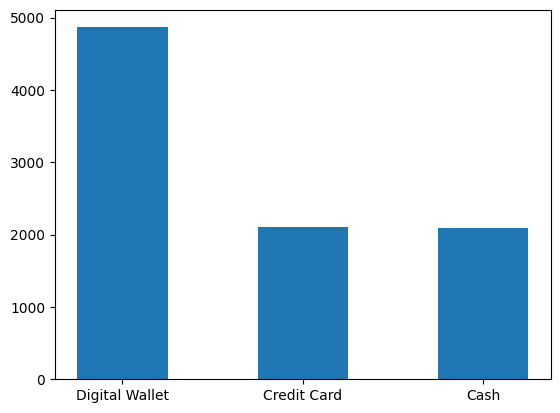

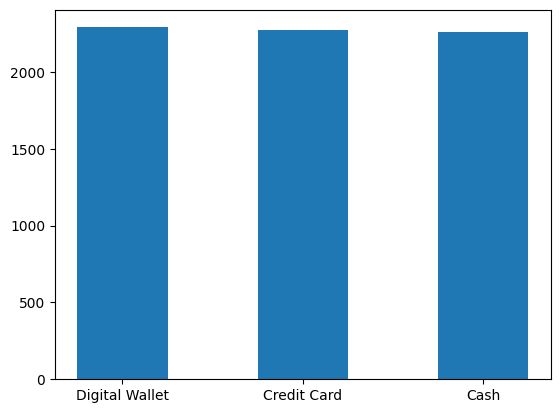

In [957]:
item_counts_after = data['Payment Method'].value_counts()

plt.bar( item_counts_after.index,item_counts_after.values, width=0.5)
plt.show()
item_counts_before = data_clone['Payment Method'].value_counts()
plt.bar(item_counts_before.index, item_counts_before.values, width=0.5)
plt.show()